# 06. Analysis
Phân tích chi tiết kết quả backtest từ NB05.

In [1]:
import sys, logging, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ast
from collections import Counter

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s | %(name)s | %(message)s')
warnings.filterwarnings('ignore')

from src.utils.io import save, load
from src.config import load_config
from src.backtest import BacktestEngineConfig, run_backtest, compute_benchmark, compute_metrics, compute_alpha_stats

cfg = load_config(ROOT / 'configs' / 'base.yaml')


## 1. Load results từ NB05

In [2]:
eq_full = load(cfg.dir_outputs / 'equity_full.parquet')
eq_bench = load(cfg.dir_outputs / 'equity_benchmark.parquet')
try:
    eq_base = load(cfg.dir_outputs / 'equity_base.parquet')
except: eq_base = None

df = load(cfg.dir_processed / 'dataset_labeled.parquet')
pred_ens_full = load(cfg.dir_processed / 'predictions_ens_full.parquet')
trades_full = pd.read_csv(cfg.dir_outputs / 'metrics' / 'trade_log_full.csv')

m_full = compute_metrics(eq_full)
m_bench = compute_metrics(eq_bench)
print(f'ML Full: CAGR={m_full["CAGR"]:.1%}, Sharpe={m_full["Sharpe"]:.2f}, MDD={m_full["Max_Drawdown"]:.1%}')
print(f'B&H:     CAGR={m_bench["CAGR"]:.1%}, Sharpe={m_bench["Sharpe"]:.2f}, MDD={m_bench["Max_Drawdown"]:.1%}')


ML Full: CAGR=28.5%, Sharpe=0.95, MDD=-24.2%
B&H:     CAGR=27.0%, Sharpe=0.89, MDD=-35.5%


In [3]:
# ── CELL 5: Performance Metrics ───────────────────────────────
m_full = compute_metrics(eq_full)
m_base = compute_metrics(eq_base)
m_bench = compute_metrics(eq_bench)
 
metrics_df = pd.DataFrame({
    'ML_Full':  m_full,
    'ML_Base':  m_base,
    'Buy&Hold': m_bench,
}).T
 
print('═' * 70)
print('PERFORMANCE METRICS')
print('═' * 70)
print(metrics_df[['CAGR', 'Sharpe', 'Sortino', 'Max_Drawdown', 'Calmar', 'VaR_95']].round(4))
print()
print(metrics_df[['Total_Return', 'Win_Rate', 'Avg_Daily_Ret', 'Std_Daily_Ret', 'N_Days']].round(4))

══════════════════════════════════════════════════════════════════════
PERFORMANCE METRICS
══════════════════════════════════════════════════════════════════════
            CAGR  Sharpe  Sortino  Max_Drawdown  Calmar  VaR_95
ML_Full   0.2849  0.9459   1.2927       -0.2415  1.1797 -0.0240
ML_Base   0.2505  0.8845   1.2012       -0.2394  1.0465 -0.0227
Buy&Hold  0.2703  0.8886   1.2201       -0.3546  0.7623 -0.0282

          Total_Return  Win_Rate  Avg_Daily_Ret  Std_Daily_Ret  N_Days
ML_Full         3.5741    0.5447         0.0012         0.0171  1476.0
ML_Base         2.8794    0.5522         0.0010         0.0160  1476.0
Buy&Hold        3.2678    0.5671         0.0011         0.0175  1476.0


In [4]:
# ── CELL 6: Alpha Statistics (IR, t-test) ─────────────────────
alpha_full = compute_alpha_stats(eq_full, eq_bench)
alpha_base = compute_alpha_stats(eq_base, eq_bench)
 
print('═' * 70)
print('ALPHA STATISTICS')
print('═' * 70)
for name, stats in [("ML Full vs B&H", alpha_full), ("ML Base vs B&H", alpha_base)]:
    print(f"\n{name}:")
    print(f"  Information Ratio:  {stats['Information_Ratio']:.3f}")
    print(f"  Annual Alpha:       {stats['Avg_Annual_Alpha']:.2%}")
    print(f"  Tracking Error:     {stats['Tracking_Error_Annual']:.2%}")
    print(f"  t-stat:             {stats['t_stat_alpha']:.3f}")
    print(f"  p-value:            {stats['p_value_alpha']:.4f}")
    sig = "***" if stats['p_value_alpha'] < 0.01 else "**" if stats['p_value_alpha'] < 0.05 else "*" if stats['p_value_alpha'] < 0.10 else "n.s."
    print(f"  Significance:       {sig}")

══════════════════════════════════════════════════════════════════════
ALPHA STATISTICS
══════════════════════════════════════════════════════════════════════

ML Full vs B&H:
  Information Ratio:  0.070
  Annual Alpha:       1.00%
  Tracking Error:     14.27%
  t-stat:             0.174
  p-value:            0.8621
  Significance:       n.s.

ML Base vs B&H:
  Information Ratio:  -0.158
  Annual Alpha:       -2.30%
  Tracking Error:     14.54%
  t-stat:             -0.396
  p-value:            0.6918
  Significance:       n.s.


In [5]:
# ── CELL 7: Annual Returns ────────────────────────────────────
print('═' * 70)
print('ANNUAL RETURNS')
print('═' * 70)
for name, eq in [("ML Full", eq_full), ("ML Base", eq_base), ("Buy&Hold", eq_bench)]:
    annual = eq['daily_ret'].resample('YE').apply(lambda x: (1+x).prod()-1)
    print(f"\n{name}:")
    for date, ret in annual.items():
        print(f"  {date.year}: {ret:+.1%}")
 
# Alpha per year
print("\nAlpha (ML Full - Buy&Hold):")
for year in range(2020, 2027):
    ml_mask = eq_full.index.year == year
    bh_mask = eq_bench.index.year == year
    if ml_mask.sum() == 0:
        continue
    ml_ret = eq_full.loc[ml_mask, 'equity'].iloc[-1] / eq_full.loc[ml_mask, 'equity'].iloc[0] - 1
    bh_ret = eq_bench.loc[bh_mask, 'equity'].iloc[-1] / eq_bench.loc[bh_mask, 'equity'].iloc[0] - 1
    alpha = ml_ret - bh_ret
    print(f"  {year}: alpha={alpha:+.1%}")

══════════════════════════════════════════════════════════════════════
ANNUAL RETURNS
══════════════════════════════════════════════════════════════════════

ML Full:
  2020: +84.1%
  2021: +28.9%
  2022: -11.8%
  2023: +63.3%
  2024: +5.1%
  2025: +18.7%
  2026: +7.3%

ML Base:
  2020: +62.1%
  2021: +32.0%
  2022: -10.6%
  2023: +38.8%
  2024: +8.4%
  2025: +34.2%
  2026: +0.5%

Buy&Hold:
  2020: +52.2%
  2021: +39.6%
  2022: -30.8%
  2023: +63.1%
  2024: +36.2%
  2025: +27.8%
  2026: +2.1%

Alpha (ML Full - Buy&Hold):
  2020: alpha=+33.0%
  2021: alpha=-10.0%
  2022: alpha=+20.1%
  2023: alpha=-1.2%
  2024: alpha=-33.6%
  2025: alpha=-8.4%
  2026: alpha=+4.8%


In [6]:
# ── CELL 8: Trade Log Analysis ────────────────────────────────
import ast
from collections import Counter
 
print('═' * 70)
print('TRADE LOG')
print('═' * 70)
print(f'Total rebalances: {len(trades_full)}')
print(f'Avg n_holdings:   {trades_full["n_holdings"].mean():.1f}')
print(f'Total cost:       {trades_full["cost"].sum():.4f} ({trades_full["cost"].sum()*100:.2f}%)')
print(f'\nn_holdings distribution:')
print(trades_full['n_holdings'].value_counts().sort_index())
 
# Top picks
all_picks = []
for h in trades_full['holdings']:
    holdings = ast.literal_eval(h) if isinstance(h, str) else h
    all_picks.extend(holdings)
counts = Counter(all_picks)
print(f"\nTop 10 picks — ML Full:")
for tkr, n in counts.most_common(10):
    print(f"  {tkr}: {n}/{len(trades_full)} ({n/len(trades_full):.0%})")

══════════════════════════════════════════════════════════════════════
TRADE LOG
══════════════════════════════════════════════════════════════════════
Total rebalances: 142
Avg n_holdings:   10.0
Total cost:       0.1423 (14.23%)

n_holdings distribution:
n_holdings
8       1
9       2
10    139
Name: count, dtype: int64

Top 10 picks — ML Full:
  FAST: 75/142 (53%)
  MDLZ: 67/142 (47%)
  SBUX: 66/142 (46%)
  MNST: 66/142 (46%)
  INTC: 65/142 (46%)
  EBAY: 63/142 (44%)
  NFLX: 62/142 (44%)
  GILD: 61/142 (43%)
  GOOGL: 60/142 (42%)
  NVDA: 60/142 (42%)


In [7]:
# ── CELL 9: VXN-based analysis ────────────────────────────────
# Xem model chọn gì khi VXN cao vs thấp
first_tkr = df.index.get_level_values("ticker").unique()[0]
high_vxn_picks = []
low_vxn_picks = []
 
for _, row in trades_full.iterrows():
    date = row['rebalance_date']
    macro = df.xs(first_tkr, level="ticker").loc[:date]
    vxn = macro["vxn"].iloc[-2]  # t-1
 
    h = row['holdings']
    holdings = ast.literal_eval(h) if isinstance(h, str) else h
 
    if vxn >= 25:
        high_vxn_picks.extend(holdings)
    else:
        low_vxn_picks.extend(holdings)
 
print("=== Khi VXN >= 25 (thị trường biến động) ===")
print(Counter(high_vxn_picks).most_common(10))
 
print("\n=== Khi VXN < 25 (bình thường) ===")
print(Counter(low_vxn_picks).most_common(10))

=== Khi VXN >= 25 (thị trường biến động) ===
[('GOOGL', 34), ('NVDA', 33), ('INTC', 28), ('AAPL', 28), ('AVGO', 27), ('AMZN', 25), ('SBUX', 23), ('NFLX', 23), ('AMD', 22), ('PANW', 21)]

=== Khi VXN < 25 (bình thường) ===
[('FAST', 55), ('MDLZ', 49), ('GILD', 46), ('MNST', 46), ('EBAY', 45), ('SBUX', 43), ('NFLX', 39), ('PAYX', 37), ('INTC', 37), ('PEP', 37)]


In [8]:
# ── CELL 10: Model Confidence over time ───────────────────────
print('═' * 70)
print('MODEL CONFIDENCE')
print('═' * 70)
for year in range(2020, 2027):
    year_preds = pred_ens_full[pred_ens_full.index.get_level_values('date').year == year]
    if len(year_preds) == 0:
        continue
    top10_probs = []
    for date, grp in year_preds.groupby(level='date'):
        top10 = grp.nlargest(10, 'y_prob')
        top10_probs.append(top10['y_prob'].mean())
    avg_prob = np.mean(top10_probs)
    std_prob = np.std(top10_probs)
    print(f"  {year}: avg_y_prob={avg_prob:.3f}  std={std_prob:.3f}")

══════════════════════════════════════════════════════════════════════
MODEL CONFIDENCE
══════════════════════════════════════════════════════════════════════
  2020: avg_y_prob=0.532  std=0.053
  2021: avg_y_prob=0.512  std=0.035
  2022: avg_y_prob=0.555  std=0.031
  2023: avg_y_prob=0.496  std=0.019
  2024: avg_y_prob=0.510  std=0.025
  2025: avg_y_prob=0.517  std=0.028
  2026: avg_y_prob=0.494  std=0.017


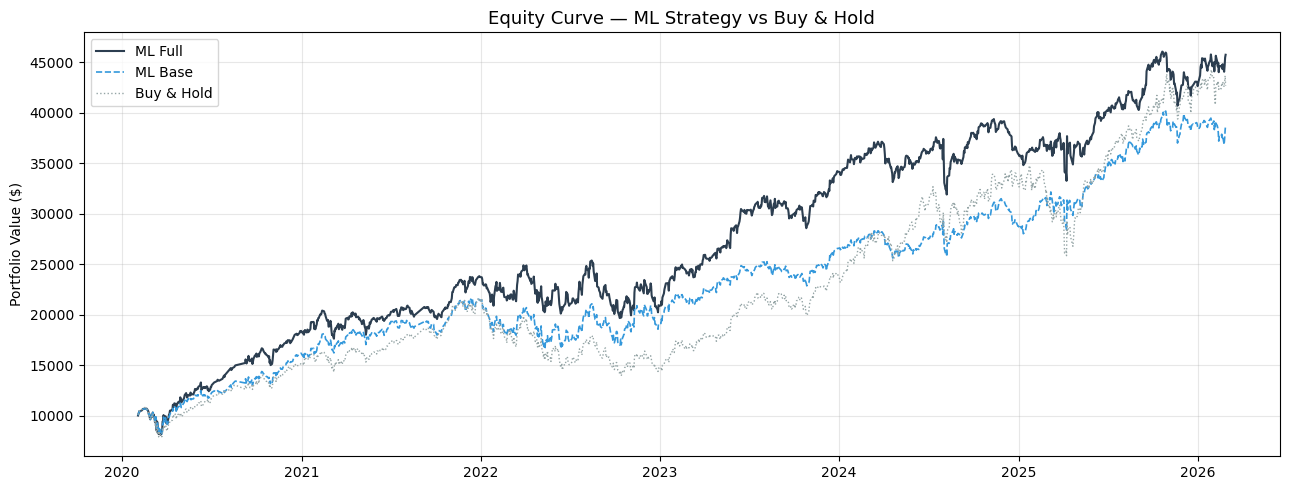

In [9]:
# ── CELL 11: Equity Curves Plot ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(eq_full.index, eq_full['equity'], lw=1.5, label='ML Full', color='#2c3e50')
ax.plot(eq_base.index, eq_base['equity'], lw=1.2, label='ML Base', color='#3498db', ls='--')
ax.plot(eq_bench.index, eq_bench['equity'], lw=1, label='Buy & Hold', color='#95a5a6', ls=':')
 
ax.set_title('Equity Curve — ML Strategy vs Buy & Hold', fontsize=13)
ax.set_ylabel('Portfolio Value ($)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

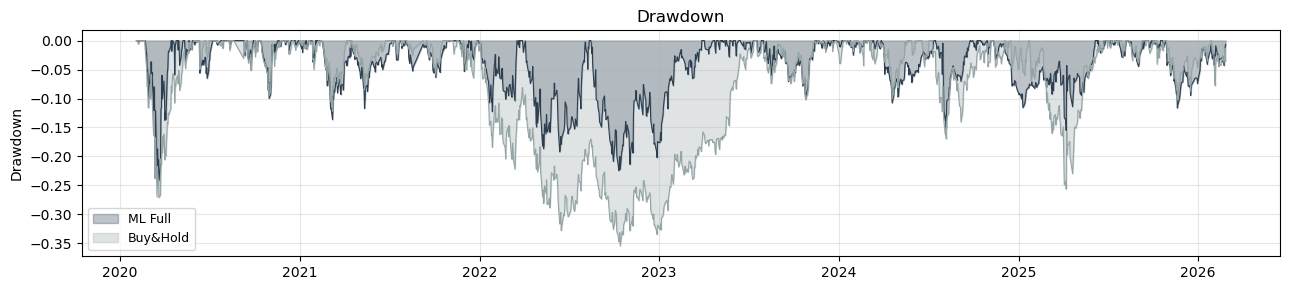

In [10]:
# ── CELL 12: Drawdown Plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))
for eq, label, color in [
    (eq_full, 'ML Full', '#2c3e50'),
    (eq_bench, 'Buy&Hold', '#95a5a6'),
]:
    rolling_max = eq['equity'].cummax()
    dd = (eq['equity'] - rolling_max) / rolling_max
    ax.fill_between(eq.index, dd, alpha=0.3, color=color, label=label)
    ax.plot(eq.index, dd, lw=0.8, color=color)
 
ax.set_title('Drawdown', fontsize=12)
ax.set_ylabel('Drawdown')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

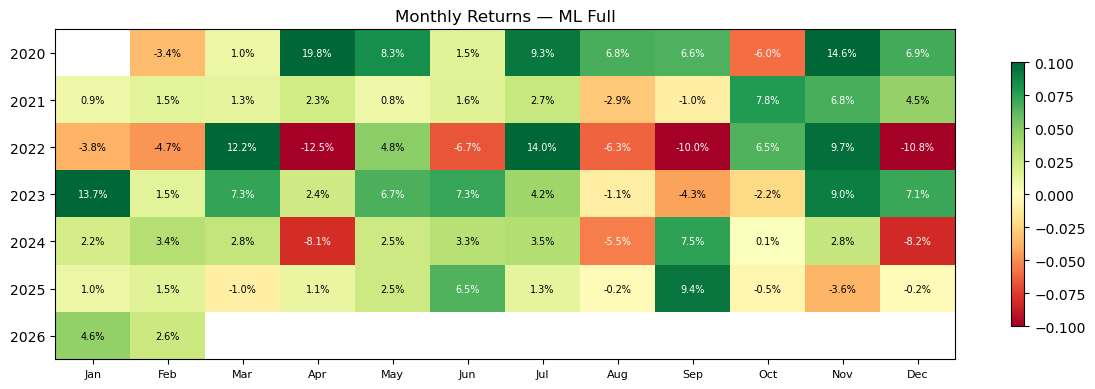

In [11]:
# ── CELL 13: Monthly Returns Heatmap ──────────────────────────
monthly = eq_full['daily_ret'].resample('M').apply(lambda x: (1+x).prod()-1)
monthly_df = monthly.to_frame('ret')
monthly_df['year'] = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot_table(index='year', columns='month', values='ret')
 
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1%}', ha='center', va='center', fontsize=7,
                    color='black' if abs(v) < 0.05 else 'white')
ax.set_title('Monthly Returns — ML Full', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

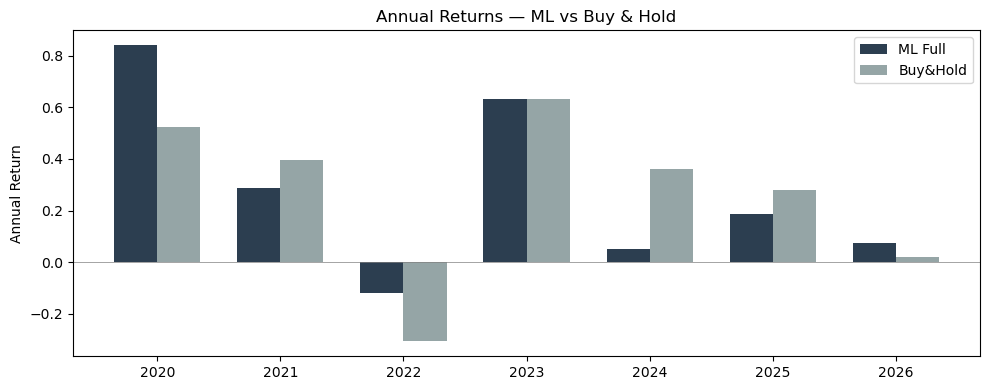

In [12]:
# ── CELL 14: Annual Returns Bar Chart ─────────────────────────
annual_full = eq_full['daily_ret'].resample('YE').apply(lambda x: (1+x).prod()-1)
annual_bench = eq_bench['daily_ret'].resample('YE').apply(lambda x: (1+x).prod()-1)
 
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(annual_full))
w = 0.35
ax.bar([i-w/2 for i in x], annual_full.values, w, label='ML Full', color='#2c3e50')
ax.bar([i+w/2 for i in x], annual_bench.values[:len(annual_full)], w, label='Buy&Hold', color='#95a5a6')
ax.set_xticks(x)
ax.set_xticklabels([d.year for d in annual_full.index])
ax.set_ylabel('Annual Return')
ax.set_title('Annual Returns — ML vs Buy & Hold', fontsize=12)
ax.axhline(0, color='gray', lw=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# ── CELL 15: Period Analysis ──────────────────────────────────
PERIODS = {
    'COVID Crash':        ('2020-02-19', '2020-03-23'),
    'COVID Recovery':     ('2020-03-23', '2020-08-31'),
    'Bull 2021':          ('2021-01-01', '2021-12-31'),
    'Rate Hike 2022':     ('2022-01-01', '2022-10-12'),
    'Recovery 2023':      ('2023-01-01', '2023-12-31'),
    'AI Rally 2024':      ('2024-01-01', '2024-12-31'),
    'Correction 2025':    ('2025-01-01', '2025-03-31'),
    'Post-Correction':    ('2025-04-01', '2025-12-31'),
}
period_order = list(PERIODS.keys())
 
def period_metrics(equity_df, start, end):
    mask = (equity_df.index >= start) & (equity_df.index <= end)
    sub = equity_df.loc[mask]
    if len(sub) < 2:
        return None
    eq = sub['equity']
    rets = sub['daily_ret']
    total_ret = eq.iloc[-1] / eq.iloc[0] - 1
    rolling_max = eq.cummax()
    dd = (eq - rolling_max) / rolling_max
    sharpe = rets.mean() / max(rets.std(), 1e-10) * np.sqrt(252)
    return {'Return': total_ret, 'Max_DD': dd.min(), 'Sharpe': sharpe}
 
rows = []
for period_name, (start, end) in PERIODS.items():
    for strat_name, eq_df in [('ML_Full', eq_full), ('ML_Base', eq_base), ('Buy&Hold', eq_bench)]:
        m = period_metrics(eq_df, start, end)
        if m:
            rows.append({'Period': period_name, 'Strategy': strat_name, **m})
 
period_df = pd.DataFrame(rows)
 
# Return pivot
pivot_ret = period_df.pivot_table(index='Period', columns='Strategy', values='Return', aggfunc='first')
pivot_ret = pivot_ret.reindex([p for p in period_order if p in pivot_ret.index])
print('Return theo giai đoạn:\n')
print((pivot_ret * 100).round(1).to_string())
 
# MDD pivot
pivot_dd = period_df.pivot_table(index='Period', columns='Strategy', values='Max_DD', aggfunc='first')
pivot_dd = pivot_dd.reindex([p for p in period_order if p in pivot_dd.index])
print('\n\nMax Drawdown theo giai đoạn:\n')
print((pivot_dd * 100).round(1).to_string())

Return theo giai đoạn:

Strategy         Buy&Hold  ML_Base  ML_Full
Period                                     
COVID Crash         -26.6    -22.9    -21.7
COVID Recovery       63.8     63.4     78.6
Bull 2021            40.7     34.6     30.7
Rate Hike 2022      -34.6    -20.4    -16.7
Recovery 2023        64.6     38.7     63.4
AI Rally 2024        38.7      8.1      5.2
Correction 2025     -11.1      8.1      2.1
Post-Correction      42.6     24.1     16.4


Max Drawdown theo giai đoạn:

Strategy         Buy&Hold  ML_Base  ML_Full
Period                                     
COVID Crash         -27.1    -23.9    -24.2
COVID Recovery       -5.4     -7.5     -8.3
Bull 2021           -12.2    -10.5    -13.6
Rate Hike 2022      -34.6    -22.6    -22.5
Recovery 2023       -10.2     -9.5    -10.1
AI Rally 2024       -17.0    -12.4    -15.1
Correction 2025     -16.5     -6.7     -4.9
Post-Correction     -12.7     -9.6    -11.6


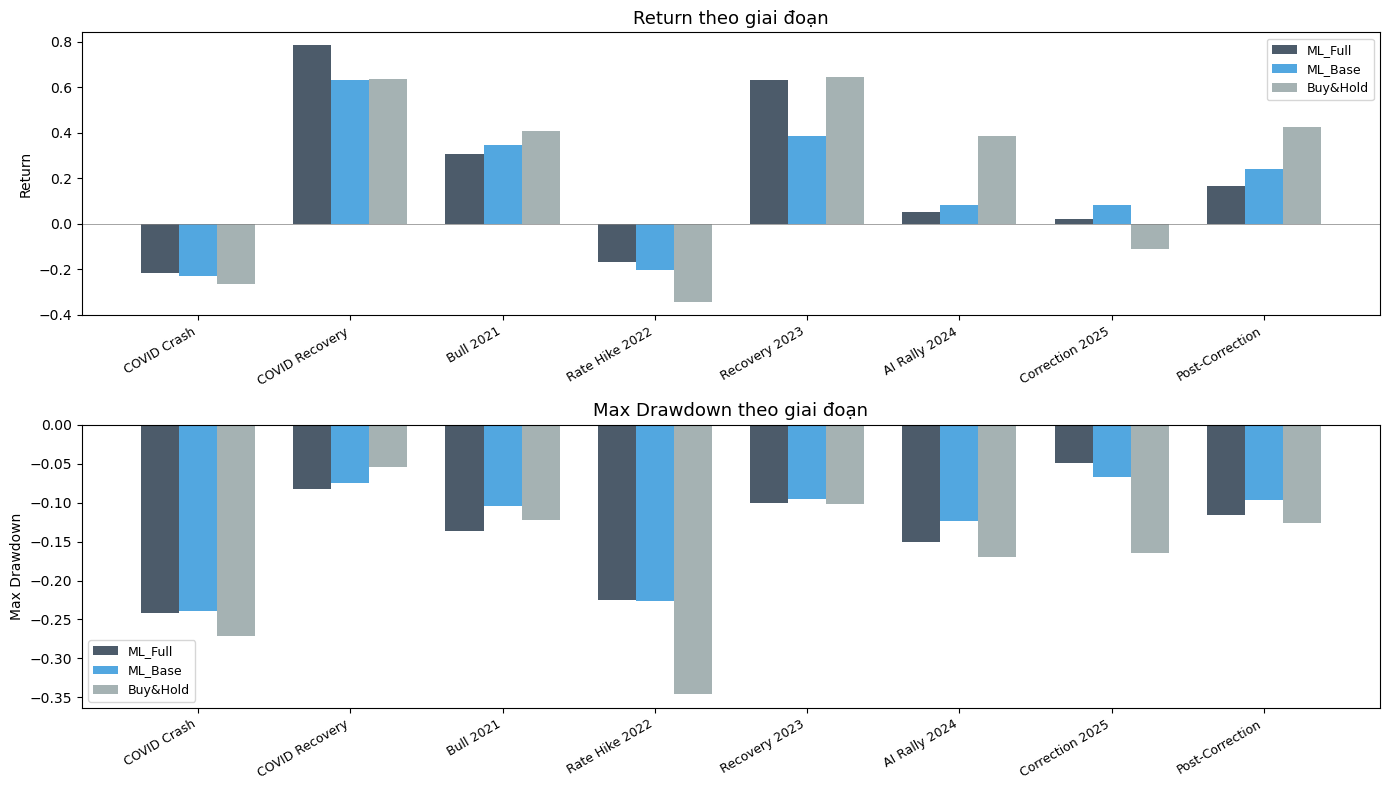

In [14]:
# ── CELL 16: Period Bar Charts ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
 
# Return chart
ret_data = pivot_ret
x = np.arange(len(ret_data))
w = 0.25
for i, (strat, color) in enumerate([('ML_Full', '#2c3e50'), ('ML_Base', '#3498db'), ('Buy&Hold', '#95a5a6')]):
    if strat in ret_data.columns:
        ax1.bar(x + i*w, ret_data[strat].values, w, label=strat, color=color, alpha=0.85)
ax1.set_xticks(x + w)
ax1.set_xticklabels(ret_data.index, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Return')
ax1.set_title('Return theo giai đoạn', fontsize=13)
ax1.axhline(0, color='gray', lw=0.5)
ax1.legend(fontsize=9)
 
# MDD chart
dd_data = pivot_dd
for i, (strat, color) in enumerate([('ML_Full', '#2c3e50'), ('ML_Base', '#3498db'), ('Buy&Hold', '#95a5a6')]):
    if strat in dd_data.columns:
        ax2.bar(x + i*w, dd_data[strat].values, w, label=strat, color=color, alpha=0.85)
ax2.set_xticks(x + w)
ax2.set_xticklabels(dd_data.index, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Max Drawdown')
ax2.set_title('Max Drawdown theo giai đoạn', fontsize=13)
ax2.axhline(0, color='gray', lw=0.5)
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.show()

In [15]:
# ── CELL 17: Win/Loss Analysis ────────────────────────────────
print('═' * 70)
print('WIN/LOSS ANALYSIS (monthly)')
print('═' * 70)
for name, eq in [("ML Full", eq_full), ("ML Base", eq_base), ("Buy&Hold", eq_bench)]:
    monthly_rets = eq['daily_ret'].resample('M').apply(lambda x: (1+x).prod()-1)
    wins = monthly_rets[monthly_rets > 0]
    losses = monthly_rets[monthly_rets <= 0]
    win_rate = len(wins) / max(len(monthly_rets), 1)
    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = losses.mean() if len(losses) > 0 else 0
    win_loss = abs(avg_win / avg_loss) if avg_loss != 0 else float('inf')
    print(f"  {name:10s}: WinRate={win_rate:.0%}  AvgWin={avg_win:+.1%}  AvgLoss={avg_loss:+.1%}  W/L={win_loss:.2f}")

══════════════════════════════════════════════════════════════════════
WIN/LOSS ANALYSIS (monthly)
══════════════════════════════════════════════════════════════════════
  ML Full   : WinRate=70%  AvgWin=+5.3%  AvgLoss=-4.7%  W/L=1.13
  ML Base   : WinRate=66%  AvgWin=+5.3%  AvgLoss=-4.1%  W/L=1.27
  Buy&Hold  : WinRate=67%  AvgWin=+5.6%  AvgLoss=-4.7%  W/L=1.18


In [16]:
# ── CELL 18: Robustness — Top-K Sensitivity ──────────────────
print('═' * 70)
print('SENSITIVITY: TOP-K')
print('═' * 70)
topk_results = {}
for k in [3, 5, 8, 10, 12, 15]:
    bt = BacktestEngineConfig(
        top_k=k,
        rebalance_days=cfg.strategy.rebalance_days,
        cost_bps=cfg.backtest.cost_bps,
        initial_capital=cfg.backtest.initial_capital,
    )
    eq, _ = run_backtest(df, pred_ens_full, bt)
    m = compute_metrics(eq)
    topk_results[k] = m
    print(f"  K={k:2d}: CAGR={m['CAGR']:.1%}  Sharpe={m['Sharpe']:.2f}  MDD={m['Max_Drawdown']:.1%}  Calmar={m['Calmar']:.2f}")

INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


══════════════════════════════════════════════════════════════════════
SENSITIVITY: TOP-K
══════════════════════════════════════════════════════════════════════


INFO     | src.backtest.engine |   Final: $65,771 (return: 557.7%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


  K= 3: CAGR=36.4%  Sharpe=1.02  MDD=-28.2%  Calmar=1.29


INFO     | src.backtest.engine |   Final: $39,566 (return: 295.7%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


...

  K=10: CAGR=28.5%  Sharpe=0.95  MDD=-24.2%  Calmar=1.18


INFO     | src.backtest.engine |   Final: $41,578 (return: 315.8%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


  K=12: CAGR=26.5%  Sharpe=0.90  MDD=-24.6%  Calmar=1.08


INFO     | src.backtest.engine |   Final: $38,611 (return: 286.1%)


  K=15: CAGR=25.0%  Sharpe=0.86  MDD=-25.6%  Calmar=0.97


In [17]:
# ── CELL 19: Robustness — Cost Sensitivity ────────────────────
print('═' * 70)
print('SENSITIVITY: TRANSACTION COST')
print('═' * 70)
for cost in [0, 5, 10, 15, 20, 30]:
    bt = BacktestEngineConfig(
        top_k=cfg.strategy.top_k,
        rebalance_days=cfg.strategy.rebalance_days,
        cost_bps=cost,
        initial_capital=cfg.backtest.initial_capital,
    )
    eq, _ = run_backtest(df, pred_ens_full, bt)
    m = compute_metrics(eq)
    print(f"  Cost={cost:2d}bps: CAGR={m['CAGR']:.1%}  Sharpe={m['Sharpe']:.2f}  Total={m['Total_Return']:.1%}")

INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


══════════════════════════════════════════════════════════════════════
SENSITIVITY: TRANSACTION COST
══════════════════════════════════════════════════════════════════════


INFO     | src.backtest.engine |   Final: $52,741 (return: 427.4%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


  Cost= 0bps: CAGR=31.5%  Sharpe=1.04  Total=427.4%


INFO     | src.backtest.engine |   Final: $49,118 (return: 391.2%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


...

  Cost=15bps: CAGR=27.0%  Sharpe=0.90  Total=325.9%


INFO     | src.backtest.engine |   Final: $39,664 (return: 296.6%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


  Cost=20bps: CAGR=25.5%  Sharpe=0.86  Total=296.6%


INFO     | src.backtest.engine |   Final: $34,389 (return: 243.9%)


  Cost=30bps: CAGR=22.6%  Sharpe=0.77  Total=243.9%


In [18]:
# ── CELL 20: Robustness — Rebalance Frequency ────────────────
print('═' * 70)
print('SENSITIVITY: REBALANCE FREQUENCY')
print('═' * 70)
for freq in [5, 10, 15, 21, 42]:
    bt = BacktestEngineConfig(
        top_k=cfg.strategy.top_k,
        rebalance_days=freq,
        cost_bps=cfg.backtest.cost_bps,
        initial_capital=cfg.backtest.initial_capital,
    )
    eq, _ = run_backtest(df, pred_ens_full, bt)
    m = compute_metrics(eq)
    print(f"  Freq={freq:2d}d: CAGR={m['CAGR']:.1%}  Sharpe={m['Sharpe']:.2f}  MDD={m['Max_Drawdown']:.1%}")

INFO     | src.backtest.engine | Backtest: 284 rebalances, every 5 days, 2020-01-31→2026-02-26


══════════════════════════════════════════════════════════════════════
SENSITIVITY: REBALANCE FREQUENCY
══════════════════════════════════════════════════════════════════════


INFO     | src.backtest.engine |   Final: $38,240 (return: 282.4%)
INFO     | src.backtest.engine | Backtest: 142 rebalances, every 10 days, 2020-01-31→2026-02-26


  Freq= 5d: CAGR=24.8%  Sharpe=0.84  MDD=-29.4%


INFO     | src.backtest.engine |   Final: $45,741 (return: 357.4%)
INFO     | src.backtest.engine | Backtest: 95 rebalances, every 15 days, 2020-01-31→2026-02-26


...

  Freq=15d: CAGR=24.0%  Sharpe=0.81  MDD=-39.6%


INFO     | src.backtest.engine |   Final: $31,786 (return: 217.9%)
INFO     | src.backtest.engine | Backtest: 34 rebalances, every 42 days, 2020-01-31→2026-02-26


  Freq=21d: CAGR=21.0%  Sharpe=0.73  MDD=-42.6%


INFO     | src.backtest.engine |   Final: $26,128 (return: 161.3%)


  Freq=42d: CAGR=17.2%  Sharpe=0.60  MDD=-41.1%
